In [1]:
import scanpy as sc
import pandas as pd
import GEOparse
import pandas as pd
import os

os.chdir('c:\\Users\\ankit\\Documents\\scFM\\train_data\\GSE159977') 

In [2]:


gse = GEOparse.get_GEO(filepath="GSE159977_family.soft.gz")

rows = []
for gsm_name, gsm in gse.gsms.items():
    meta = gsm.metadata
    
    def first_or_none(x):
        return x[0] if isinstance(x, list) and len(x) > 0 else None
    
    # characteristics are usually a list like:
    # ["pathology: Borderline NASH", "tissue: Liver Biopsy", ...]
    chars = meta.get("characteristics_ch1", [])
    char_dict = {}
    for c in chars:
        if ": " in c:
            k, v = c.split(": ", 1)
            char_dict[k.strip()] = v.strip()
    
    rows.append({
        "gsm": gsm_name,
        "title": first_or_none(meta.get("title")),
        "source_name": first_or_none(meta.get("source_name_ch1")),
        "pathology": char_dict.get("pathology"),
        "tissue": char_dict.get("tissue"),
        "treatment": char_dict.get("treatment"),
        "sample_type": char_dict.get("sample type"),
        "sra": first_or_none(meta.get("relation")),
    })

sample_meta = pd.DataFrame(rows).sort_values("gsm")
print(sample_meta)
sample_meta.to_csv("sample_metadata_parsed.csv", index=False)

31-Mar-2026 17:40:15 INFO GEOparse - Parsing GSE159977_family.soft.gz: 
31-Mar-2026 17:40:15 DEBUG GEOparse - DATABASE: GeoMiame
31-Mar-2026 17:40:15 DEBUG GEOparse - SERIES: GSE159977
31-Mar-2026 17:40:15 DEBUG GEOparse - PLATFORM: GPL24676
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851987
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851988
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851989
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851990
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851991
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851992
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851993
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851994
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851995
31-Mar-2026 17:40:15 DEBUG GEOparse - SAMPLE: GSM4851996


          gsm                      title source_name            pathology  \
0  GSM4851987   Human Liver Biopsy  PT-5       Liver       Boderline NASH   
1  GSM4851988   Human Liver Biopsy  PT-8       Liver                 NASH   
2  GSM4851989   Human Liver Biopsy  PT-9       Liver       Boderline NASH   
3  GSM4851990  Human Liver Biopsy  PT-11       Liver       Boderline NASH   
4  GSM4851991  Human Liver Biopsy  PT-12       Liver  Healthy Human Liver   
5  GSM4851992  Human Liver Biopsy  PT-16       Liver  Healthy Human Liver   
6  GSM4851993  Human Liver Biopsy  PT-17       Liver  Healthy Human Liver   
7  GSM4851994  Human Liver Biopsy  PT-19       Liver                 NASH   
8  GSM4851995  Human Liver Biopsy  PT-20       Liver  Healthy Human Liver   
9  GSM4851996  Human Liver Biopsy  PT-21       Liver                 NASH   

         tissue                     treatment                    sample_type  \
0  Liver Biopsy  Undergoing Bariatric surgery  CD45+ Single cells from L

In [3]:
from pathlib import Path
import re

raw_dir = Path("raw_counts")
files = sorted(raw_dir.glob("*"))

for f in files[:10]:
    print(f.name)

GSM4851987_PT-5-barcodes.tsv.gz
GSM4851987_PT-5-features.tsv.gz
GSM4851987_PT-5-matrix.mtx.gz
GSM4851988_PT-8-barcodes.tsv.gz
GSM4851988_PT-8-features.tsv.gz
GSM4851988_PT-8-matrix.mtx.gz
GSM4851989_PT-9-barcodes.tsv.gz
GSM4851989_PT-9-features.tsv.gz
GSM4851989_PT-9-matrix.mtx.gz
GSM4851990_PT-11-barcodes.tsv.gz


In [4]:
from pathlib import Path
from collections import defaultdict
import shutil
import re

raw_dir = Path("raw_counts")
grouped_dir = Path("grouped_10x")
grouped_dir.mkdir(exist_ok=True)

groups = defaultdict(dict)

for f in raw_dir.iterdir():
    name = f.name
    
    # Example: GSM4851987_PT-5-barcodes.tsv.gz
    m = re.match(r"(GSM\d+)_([^_]+)-(barcodes\.tsv\.gz|features\.tsv\.gz|matrix\.mtx\.gz)$", name)
    if m:
        gsm, patient_id, kind = m.groups()
        sample_key = f"{gsm}_{patient_id}"
        groups[sample_key][kind] = f

for sample_key, d in groups.items():
    out = grouped_dir / sample_key
    out.mkdir(exist_ok=True)
    
    rename_map = {
        "barcodes.tsv.gz": "barcodes.tsv.gz",
        "features.tsv.gz": "features.tsv.gz",
        "matrix.mtx.gz": "matrix.mtx.gz",
    }
    
    for old_kind, new_name in rename_map.items():
        if old_kind in d:
            shutil.copy(d[old_kind], out / new_name)

print(f"Found {len(groups)} grouped samples")
print(sorted(groups.keys()))

Found 10 grouped samples
['GSM4851987_PT-5', 'GSM4851988_PT-8', 'GSM4851989_PT-9', 'GSM4851990_PT-11', 'GSM4851991_PT-12', 'GSM4851992_PT-16', 'GSM4851993_PT-17', 'GSM4851994_PT-19', 'GSM4851995_PT-20', 'GSM4851996_PT-21']


In [5]:
import scanpy as sc
import pandas as pd
from pathlib import Path

sample_meta = pd.read_csv("sample_metadata_parsed.csv")

adatas = []

for _, row in sample_meta.iterrows():
    gsm = row["gsm"]
    # title is like "Human Liver Biopsy PT-5"
    pt = row["title"].split()[-1]  # PT-5
    sample_key = f"{gsm}_{pt}"
    sample_path = Path("grouped_10x") / sample_key
    
    if not sample_path.exists():
        print(f"Skipping missing {sample_key}")
        continue
    
    ad = sc.read_10x_mtx(sample_path, var_names="gene_symbols", cache=True)
    ad.var_names_make_unique()
    
    ad.obs["gsm"] = gsm
    ad.obs["patient_id"] = pt
    ad.obs["title"] = row["title"]
    ad.obs["pathology"] = row["pathology"]
    ad.obs["tissue"] = row["tissue"]
    ad.obs["treatment"] = row["treatment"]
    ad.obs["sample_type"] = row["sample_type"]
    
    adatas.append(ad)

adata = sc.concat(adatas, join="outer", label="batch", keys=[a.obs["patient_id"][0] for a in adatas])
print(adata)

C:\Users\ankit\AppData\Local\Temp\ipykernel_21508\4235657288.py:33: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  adata = sc.concat(adatas, join="outer", label="batch", keys=[a.obs["patient_id"][0] for a in adatas])


AnnData object with n_obs × n_vars = 67948800 × 33694
    obs: 'gsm', 'patient_id', 'title', 'pathology', 'tissue', 'treatment', 'sample_type', 'batch'


c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
# Add a assay_type column to adata.obs
adata.obs['assay_type'] = 'scRNA-seq'

In [7]:
# Save the processed AnnData object for future use
adata.write("GSE159977_processed.h5ad")

In [2]:
# Read in the processed data
adata = sc.read_h5ad("GSE159977_processed.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 67948800 × 33694
    obs: 'gsm', 'patient_id', 'title', 'pathology', 'tissue', 'treatment', 'sample_type', 'batch', 'assay_type'


c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


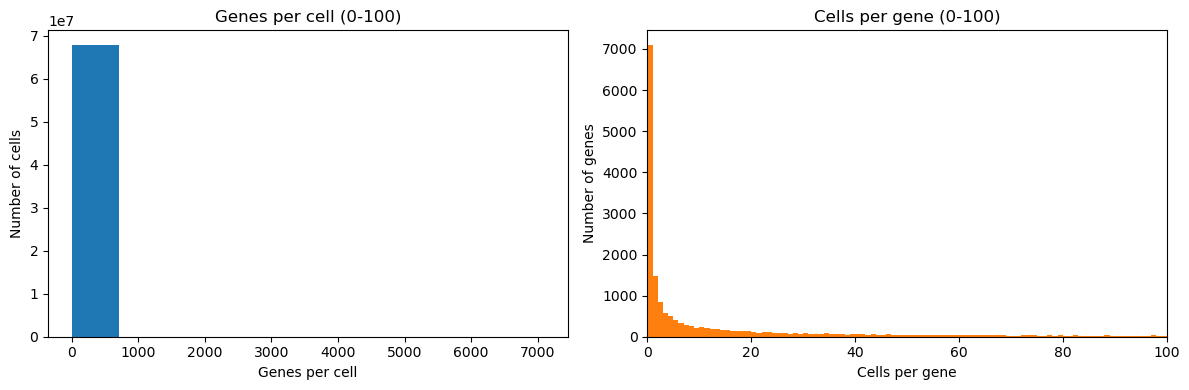

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

X = adata.X

if sparse.issparse(X):
    X = X.tocsc()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    genes_per_cell = np.sum(X > 0, axis=1)
    cells_per_gene = np.sum(X > 0, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(genes_per_cell)#, bins=np.arange(0, 102), color="C0")#,=(0, 100))
#axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Genes per cell")
axes[0].set_ylabel("Number of cells")
axes[0].set_title("Genes per cell (0-100)")

axes[1].hist(cells_per_gene, bins=np.arange(0, 102), range=(0, 100), color="C1")
axes[1].set_xlim(0, 100)
axes[1].set_xlabel("Cells per gene")
axes[1].set_ylabel("Number of genes")
axes[1].set_title("Cells per gene (0-100)")

plt.tight_layout()
plt.show()

In [4]:
# Determine the minimum and maximum number of genes per cell
min_genes_per_cell = np.min(genes_per_cell)
print(f"Minimum number of genes per cell: {min_genes_per_cell}")
# Determine how many cells have at least the minimum number of genes
num_cells_with_min_genes = np.sum(genes_per_cell == min_genes_per_cell)
print(f"Number of cells with at least {min_genes_per_cell} genes: {num_cells_with_min_genes}")

Minimum number of genes per cell: 0
Number of cells with at least 0 genes: 57025068


In [5]:
# Filter out cells with zero genes
nonzero_cells = genes_per_cell > 0
adata_nonzero = adata[nonzero_cells].copy()
print(f"Original number of cells: {adata.n_obs}")
print(f"Number of cells after filtering out zero-gene cells: {adata_nonzero.n_obs}")

Original number of cells: 67948800
Number of cells after filtering out zero-gene cells: 10923732


c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
print(adata_nonzero)

AnnData object with n_obs × n_vars = 10923732 × 33694
    obs: 'gsm', 'patient_id', 'title', 'pathology', 'tissue', 'treatment', 'sample_type', 'batch', 'assay_type'


In [7]:
# Save the processed AnnData object for future use
adata_nonzero.write("GSE159977_processed.h5ad")

In [8]:
# View sample of adata transcriptomic data
print(adata.X[:100, :100])

# View assay type column head
print(adata.obs['assay_type'].head())

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 0 stored elements and shape (100, 100)>
AAACCCAAGAAACACT-1    scRNA-seq
AAACCCAAGAAACCAT-1    scRNA-seq
AAACCCAAGAAACCCA-1    scRNA-seq
AAACCCAAGAAACCCG-1    scRNA-seq
AAACCCAAGAAACCTG-1    scRNA-seq
Name: assay_type, dtype: category
Categories (1, object): ['scRNA-seq']
